In [9]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
import random
from matplotlib.animation import FuncAnimation

In [10]:
def obstruido(maze, pos, orientacion):
    """Percepto: Verifica si hay una pared frente al robot"""
    r, c = pos
    lados = {'N': (-1,0), 'S': (1,0), 'E': (0,1), 'O': (0,-1)}
    dr, dc = lados.get(orientacion, (0,0))

    if 0 <= r + dr < maze.shape[0] and 0 <= c + dc < maze.shape[1]:
        return 1 if maze[r + dr, c + dc] == 1 else 0
    return 1

def hierarchy_pos(G, root, level_gap=3, node_gap=2):
    from collections import deque

    levels = {}
    visited = set()
    queue = deque([(root, 0)])

    while queue:
        node, depth = queue.popleft()
        if node in visited:
            continue
        visited.add(node)

        if depth not in levels:
            levels[depth] = []
        levels[depth].append(node)

        for child in G.successors(node):
            queue.append((child, depth + 1))

    pos = {}
    for depth, nodes in levels.items():
        width = len(nodes)
        for i, node in enumerate(nodes):
            x = depth * level_gap
            y = (i - width/2) * node_gap
            pos[node] = (x, y)

    return pos


def draw_tree(tree, root):
    pos = hierarchy_pos(tree, root)

    plt.figure(figsize=(16, 12))
    nx.draw(tree, pos,
            with_labels=True,
            node_size=800,
            node_color="#BDE0FE",
            edge_color="#555",
            font_size=7,
            arrows=True,
            arrowsize=12)

    plt.margins(0.2)
    plt.show()

def generar_laberinto(m, n):
    filas, cols = 2 * m + 1, 2 * n + 1
    maze = np.ones((filas, cols), dtype=int)
    start_r = (filas // 2) // 2 * 2 + 1
    start_c = (cols // 2) // 2 * 2 + 1
    maze[start_r, start_c] = 0
    pila = [(start_r, start_c)]
    visitados = {(start_r, start_c)}

    while pila:
        r, c = pila[-1]
        vecinos = []
        for dr, dc in [(-2, 0), (2, 0), (0, -2), (0, 2)]:
            nr, nc = r + dr, c + dc
            if 1 <= nr < filas-1 and 1 <= nc < cols-1 and (nr, nc) not in visitados:
                vecinos.append((nr, nc))
        if vecinos:
            pr, pc = random.choice(vecinos)
            maze[r + (pr - r) // 2, c + (pc - c) // 2] = 0
            maze[pr, pc] = 0
            visitados.add((pr, pc))
            pila.append((pr, pc))
        else:
            pila.pop()

    lado = random.choice(['N','S','E','O'])
    if lado == 'N': goal = (0, random.randrange(1, cols - 1, 2))
    elif lado == 'S': goal = (filas - 1, random.randrange(1, cols - 1, 2))
    elif lado == 'E': goal = (random.randrange(1, filas - 1, 2), cols - 1)
    else: goal = (random.randrange(1, filas - 1, 2), 0)
    maze[goal] = 0
    return maze, (start_r, start_c), goal

In [11]:
# Estructuras de Búsqueda
class Node:
    def __init__(self, state, parent=None, action=None):
        self.state = state
        self.parent = parent
        self.action = action
        self.children = []

    def expand(self, problem):
        return [Node(problem.result(self.state, act), self, act)
                for act in problem.actions(self.state)]

    def path(self):
        node, path_back = self, []
        while node:
            path_back.append(node)
            node = node.parent
        return list(reversed(path_back))

class MazeProblem:
    def __init__(self, maze, initial, goal):
        self.maze = maze
        self.initial = initial
        self.goal = goal

    def actions(self, state):
        r, c = state
        acts = []
        for m, (dr, dc) in {'N':(-1,0), 'S':(1,0), 'E':(0,1), 'O':(0,-1)}.items():
            nr, nc = r+dr, c+dc
            if 0 <= nr < self.maze.shape[0] and 0 <= nc < self.maze.shape[1] and self.maze[nr,nc] == 0:
                acts.append(m)
        return acts

    def result(self, state, action):
        dr, dc = {'N':(-1,0), 'S':(1,0), 'E':(0,1), 'O':(0,-1)}[action]
        return (state[0] + dr, state[1] + dc)

    def goal_test(self, state):
        return state == self.goal

def depth_first_graph_search(problem):
    root = Node(problem.initial)
    frontier = [root]
    visited = set()

    tree = nx.DiGraph()
    tree.add_node(root.state)

    while frontier:
        node = frontier.pop()

        if node.state in visited:
            continue

        visited.add(node.state)

        if problem.goal_test(node.state):
            return node, tree

        for action in problem.actions(node.state):
            child_state = problem.result(node.state, action)
            child_node = Node(child_state, parent=node, action=action)

            node.children.append(child_node)

            frontier.append(child_node)

            tree.add_node(child_state)
            tree.add_edge(node.state, child_state)

    return None, tree

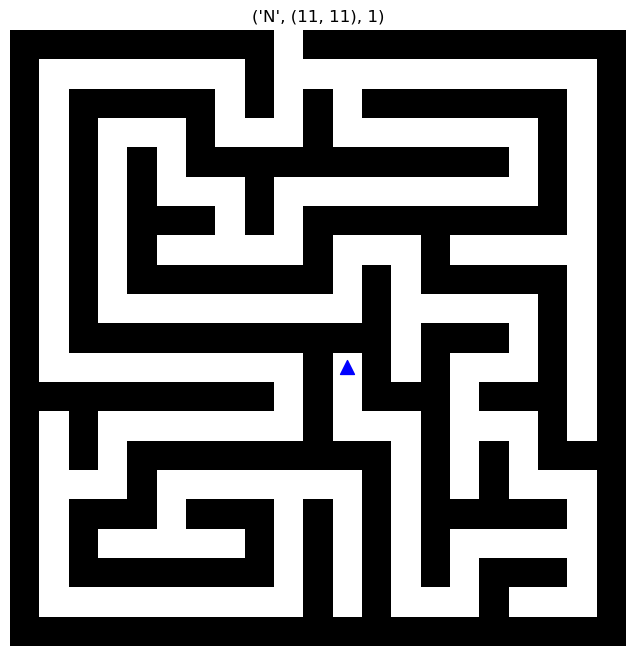

In [13]:
# Ejecución

m, n = 10, 10
maze, inicio, meta = generar_laberinto(m, n)
problem = MazeProblem(maze, inicio, meta)
sol_node, tree = depth_first_graph_search(problem)

if sol_node:
    path_nodes = sol_node.path()
    path_coords = [n.state for n in path_nodes]
    path_actions = [n.action if n.action else 'N' for n in path_nodes]

    fig, ax = plt.subplots(figsize=(8, 8))
    cmap = mcolors.ListedColormap(['white', 'black'])
    marcadores = {'N': '^', 'S': 'v', 'E': '>', 'O': '<'}

    def update(frame):
        ax.clear()
        ax.imshow(maze, cmap=cmap)
        # Dibujar rastro
        if frame > 0:
            py, px = zip(*path_coords[:frame+1])
            ax.plot(px, py, color='red', alpha=0.4, linewidth=2)

        pos = path_coords[frame]
        dir = path_actions[frame]
        ax.scatter(pos[1], pos[0], c='blue', s=100, marker=marcadores[dir])
        ax.set_title(f"{dir, pos, obstruido(maze,pos,dir)}")
        ax.set_axis_off()

    ani = FuncAnimation(fig, update, frames=len(path_coords), interval=100, repeat=False)
    ani.save('laberinto.gif', writer='pillow')